# Data Analysis
This section explores the Dry Bean dataset using descriptive statistics and visualizations to better understand its characteristics and identify potential data quality issues. The analysis includes statistical and five-number summaries, variable distributions, missing values, outlier detection, class distribution, and different visualization techniques such as boxplots, histograms, bar plots, and scatter plots. The findings from this analysis will help determine the appropriate preprocessing techniques required before applying the data mining algorithms.

In [126]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [127]:
df = pd.read_csv('Raw_dataset.csv')

df.head()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


In [128]:
numeric_columns = df.select_dtypes(include='number').columns

print(numeric_columns)

Index(['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength',
       'AspectRation', 'Eccentricity', 'ConvexArea', 'EquivDiameter', 'Extent',
       'Solidity', 'roundness', 'Compactness', 'ShapeFactor1', 'ShapeFactor2',
       'ShapeFactor3', 'ShapeFactor4'],
      dtype='str')


In [129]:
df[numeric_columns].describe()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
count,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000
mean,53048.284549,855.283459,320.141867,202.270714,1.583242,0.750895,53768.200206,253.064220,0.749733,0.987143,0.873282,0.799864,0.006564,0.001716,0.643590,0.995063
std,29324.095717,214.289696,85.694186,44.970091,0.246678,0.092002,29774.915817,59.177120,0.049086,0.004660,0.059520,0.061713,0.001128,0.000596,0.098996,0.004366
min,20420.000000,524.736000,183.601165,122.512653,1.024868,0.218951,20684.000000,161.243764,0.555315,0.919246,0.489618,0.640577,0.002778,0.000564,0.410339,0.947687
25%,36328.000000,703.523500,253.303633,175.848170,1.432307,0.715928,36714.500000,215.068003,0.718634,0.985670,0.832096,0.762469,0.005900,0.001154,0.581359,0.993703
50%,44652.000000,794.941000,296.883367,192.431733,1.551124,0.764441,45178.000000,238.438026,0.759859,0.988283,0.883157,0.801277,0.006645,0.001694,0.642044,0.996386
75%,61332.000000,977.213000,376.495012,217.031741,1.707109,0.810466,62294.000000,279.446467,0.786851,0.990013,0.916869,0.834270,0.007271,0.002170,0.696006,0.997883
max,254616.000000,1985.370000,738.860153,460.198497,2.430306,0.911423,263261.000000,569.374358,0.866195,0.994677,0.990685,0.987303,0.010451,0.003665,0.974767,0.999733


# Statistical Summary:
The statistical summary provides an overview of the 16 numerical attributes in the Dry Bean dataset. All numerical attributes contain 13,611 observations. The results show considerable differences in the scales and variability of the attributes. For example, Area ranges from 20,420 to 254,616, while attributes such as Eccentricity and Solidity are measured on much smaller scales. These differences suggest that feature scaling may be considered during the preprocessing stage, especially for distance-based algorithms such as K-means.

In [130]:
five_number_summary = pd.DataFrame({
    'Minimum': df[numeric_columns].min(),
    'Q1': df[numeric_columns].quantile(0.25),
    'Median': df[numeric_columns].median(),
    'Q3': df[numeric_columns].quantile(0.75),
    'Maximum': df[numeric_columns].max()
})

five_number_summary

,Minimum,Q1,Median,Q3,Maximum
Area,20420.000000,36328.000000,44652.000000,61332.000000,254616.000000
Perimeter,524.736000,703.523500,794.941000,977.213000,1985.370000
MajorAxisLength,183.601165,253.303633,296.883367,376.495012,738.860153
MinorAxisLength,122.512653,175.848170,192.431733,217.031741,460.198497
AspectRation,1.024868,1.432307,1.551124,1.707109,2.430306
Eccentricity,0.218951,0.715928,0.764441,0.810466,0.911423
ConvexArea,20684.000000,36714.500000,45178.000000,62294.000000,263261.000000
EquivDiameter,161.243764,215.068003,238.438026,279.446467,569.374358
Extent,0.555315,0.718634,0.759859,0.786851,0.866195
Solidity,0.919246,0.985670,0.988283,0.990013,0.994677


# Five-Number Summary:
The five-number summary presents the minimum, first quartile (Q1), median, third quartile (Q3), and maximum for each numerical attribute. The results show that some attributes have a large difference between Q3 and the maximum value. For example, Area has a Q3 of 61,332 and a maximum of 254,616, while ConvexArea has a Q3 of 62,294 and a maximum of 263,261. These large differences suggest the presence of unusually high values, which will be further examined using outlier detection and boxplots.

In [131]:
Q1 = df[numeric_columns].quantile(0.25)
Q3 = df[numeric_columns].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = ((df[numeric_columns] < lower_bound) |
            (df[numeric_columns] > upper_bound))

outlier_count = outliers.sum()

outlier_count.sort_values(ascending=False)

Eccentricity       843
Solidity           778
ShapeFactor4       767
MinorAxisLength    569
Area               551
ConvexArea         550
ShapeFactor1       533
EquivDiameter      526
Perimeter          500
AspectRation       473
MajorAxisLength    379
Extent             275
ShapeFactor3       195
Compactness        109
roundness           91
ShapeFactor2         0
dtype: int64

# Outlier Detection:
Potential outliers were identified using the Interquartile Range (IQR) method. The results show that several numerical attributes contain values outside the lower and upper IQR boundaries. Eccentricity had the highest number of detected potential outliers (843), followed by Solidity (778) and ShapeFactor4 (767). Other attributes, such as MinorAxisLength (569), Area (551), and ConvexArea (550), also contained a considerable number of potential outliers. These observations indicate that outliers should be further examined during the preprocessing stage rather than being removed automatically.

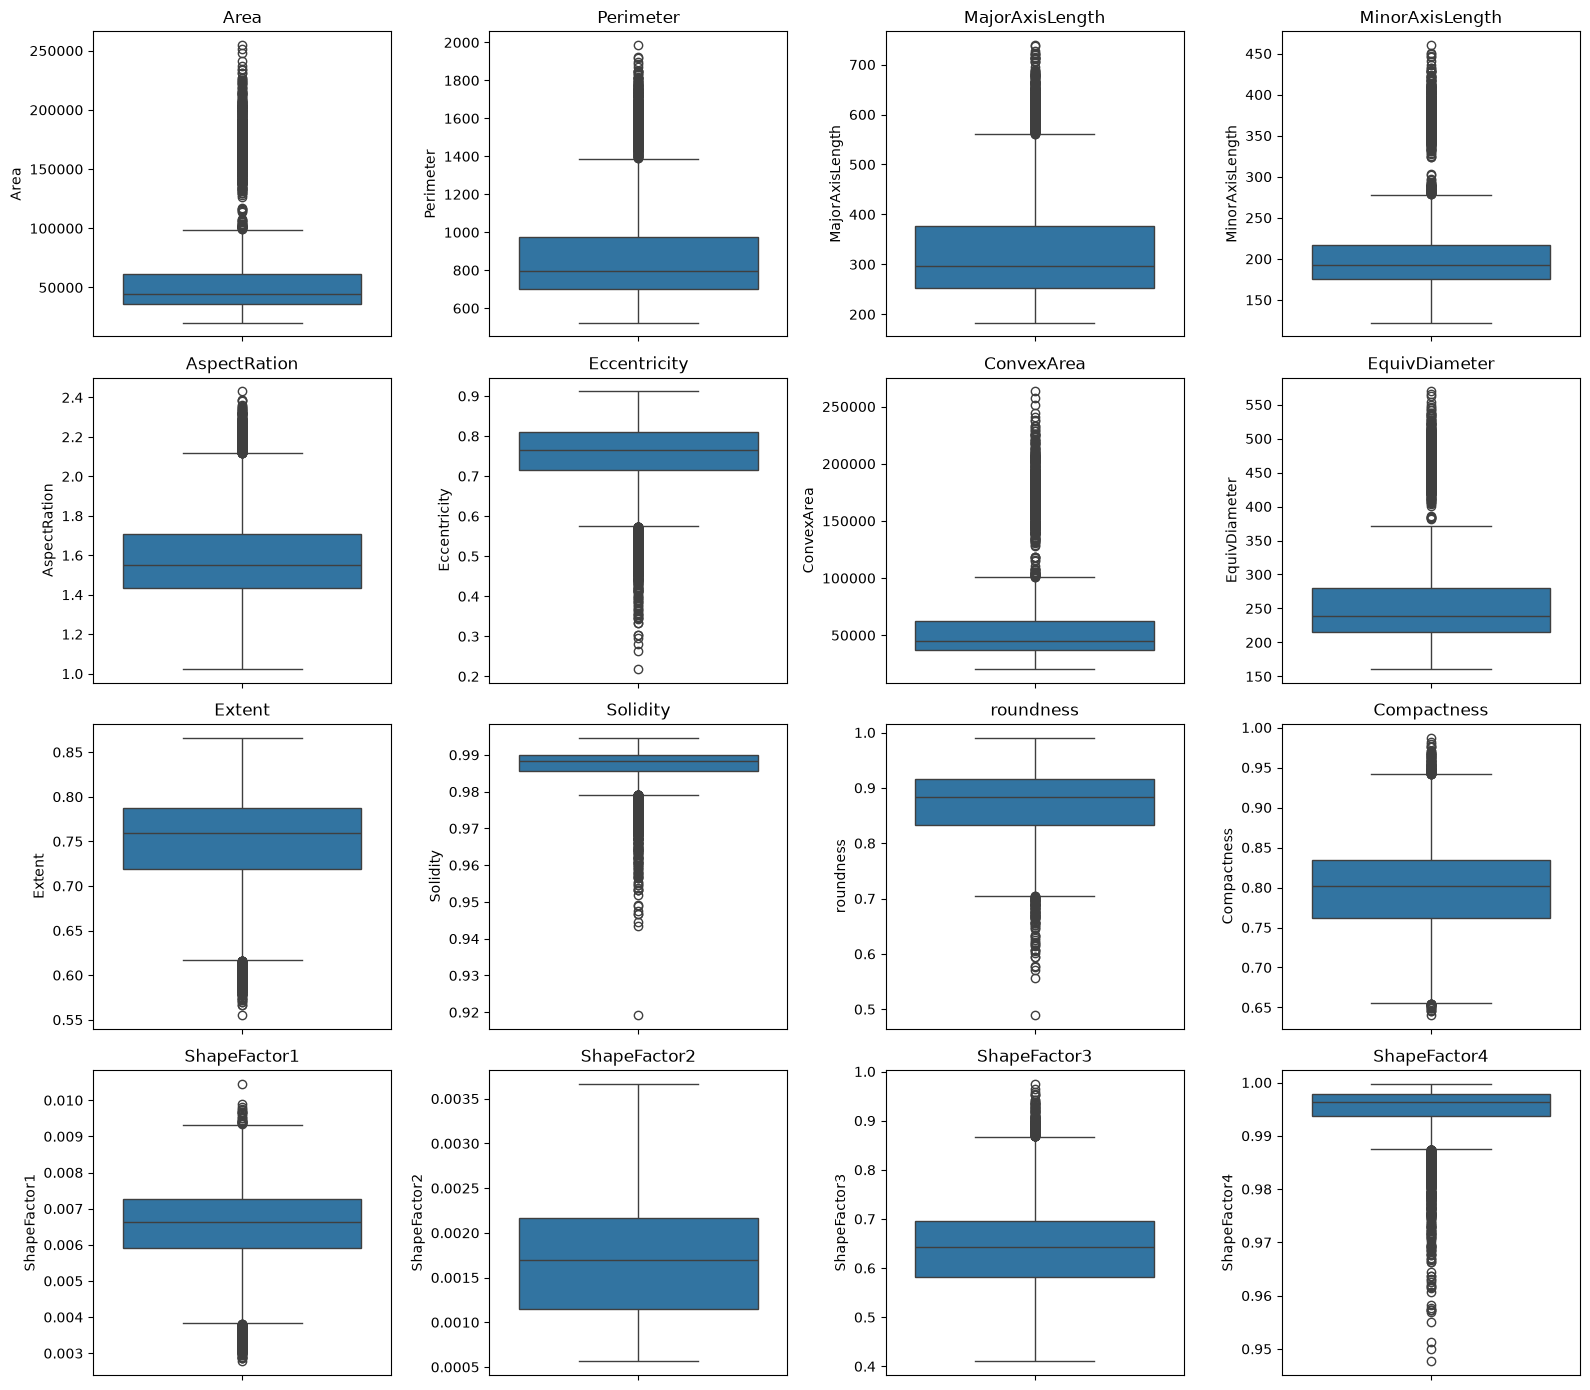

In [132]:
fig, axes = plt.subplots(4, 4, figsize=(16, 14))

for column, ax in zip(numeric_columns, axes.flatten()):
    sns.boxplot(y=df[column], ax=ax)
    ax.set_title(column)

plt.tight_layout()
plt.show()

# Boxplot Analysis:
The boxplots visually confirm the presence of potential outliers in several numerical attributes. Attributes such as Area, Perimeter, MajorAxisLength, MinorAxisLength, ConvexArea, and EquivDiameter show multiple observations beyond the whiskers, particularly toward higher values. This is consistent with the results obtained using the IQR method. The boxplots also show differences in the ranges and scales of the numerical attributes. These findings suggest that outliers and differences in feature scales should be considered during the preprocessing stage.

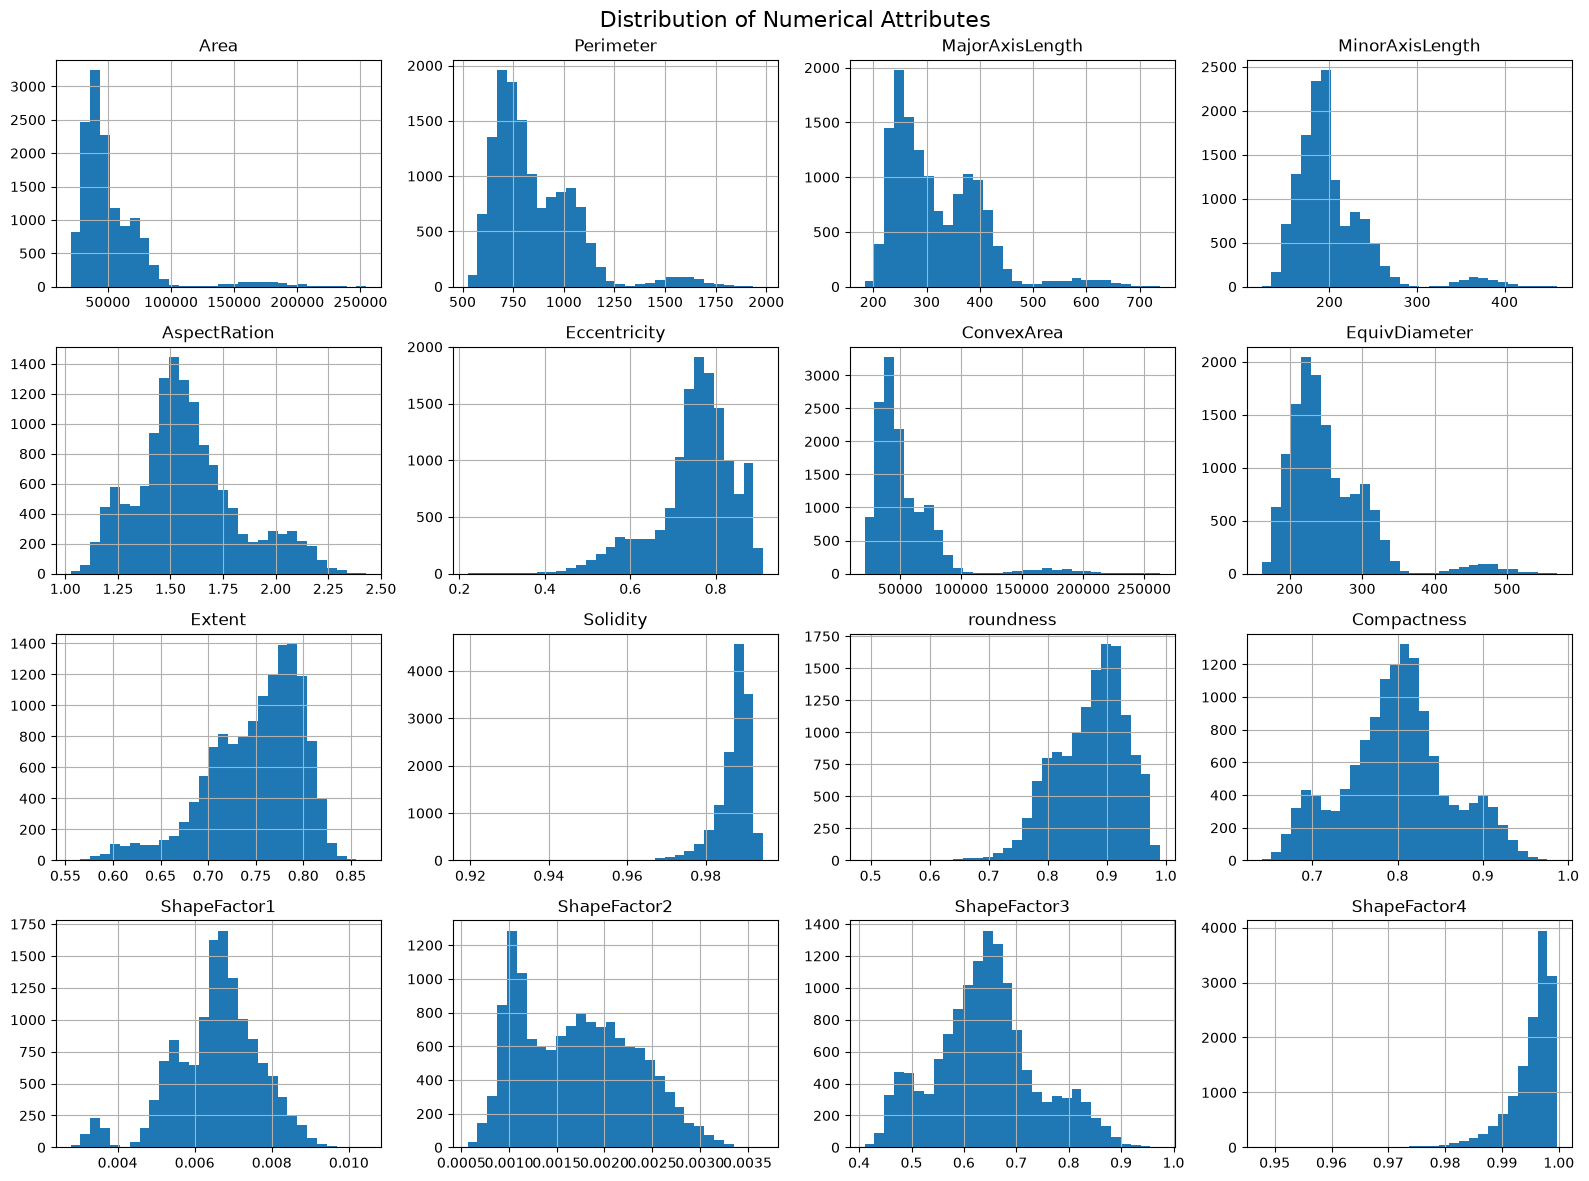

In [133]:
df[numeric_columns].hist(figsize=(16, 12), bins=30)

plt.suptitle("Distribution of Numerical Attributes", fontsize=16)
plt.tight_layout()
plt.show()

# Histogram Analysis:
The histograms show that the numerical attributes have different distribution patterns. Several attributes, such as Area and ConvexArea, are positively skewed, with most observations concentrated at lower values and a smaller number extending toward much higher values. Other attributes show different shapes and ranges, indicating that the numerical features are not distributed uniformly. These distributions, together with the previously detected outliers and differences in feature scales, suggest that appropriate preprocessing techniques should be considered before applying the data mining algorithms.

# Data Distribution and Relationships


This section analyzes missing values, class distribution, and relationships between selected numerical attributes. The results help identify whether preprocessing may be needed before applying data mining techniques.


## Check Missing Values


In [134]:
# Check for missing values in the entire dataset
missing_values = df.isna().sum()

# Display the results
print("Missing values in each column:")
print(missing_values)

# Calculate total missing values
print("\nTotal number of missing values:", missing_values.sum())

Missing values in each column:
Area               0
Perimeter          0
MajorAxisLength    0
MinorAxisLength    0
AspectRation       0
Eccentricity       0
ConvexArea         0
EquivDiameter      0
Extent             0
Solidity           0
roundness          0
Compactness        0
ShapeFactor1       0
ShapeFactor2       0
ShapeFactor3       0
ShapeFactor4       0
Class              0
dtype: int64

Total number of missing values: 0


# Missing Values Analysis
The `isna()` function identifies missing values, and `sum()` counts the missing values in each column. If the total is zero, no missing-value treatment is required for the dataset.

## Class Distribution


In [135]:
# Count the observations in each class
class_counts = df['Class'].value_counts()

# Display the class counts
print("Number of observations in each class:")
print(class_counts)

Number of observations in each class:
Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1928
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64


In [136]:
# Calculate the percentage of each class
class_percentage = df['Class'].value_counts(normalize=True) * 100

print("Percentage of observations in each class:")
print(class_percentage.round(2))

Percentage of observations in each class:
Class
DERMASON    26.05
SIRA        19.37
SEKER       14.89
HOROZ       14.17
CALI        11.98
BARBUNYA     9.71
BOMBAY       3.84
Name: proportion, dtype: float64


# Class Distribution Analysis
The class distribution shows how many observations belong to each dry bean class. Comparing the class counts helps determine whether the classes are similarly represented or whether some classes have more observations than others.

## Bar Plot


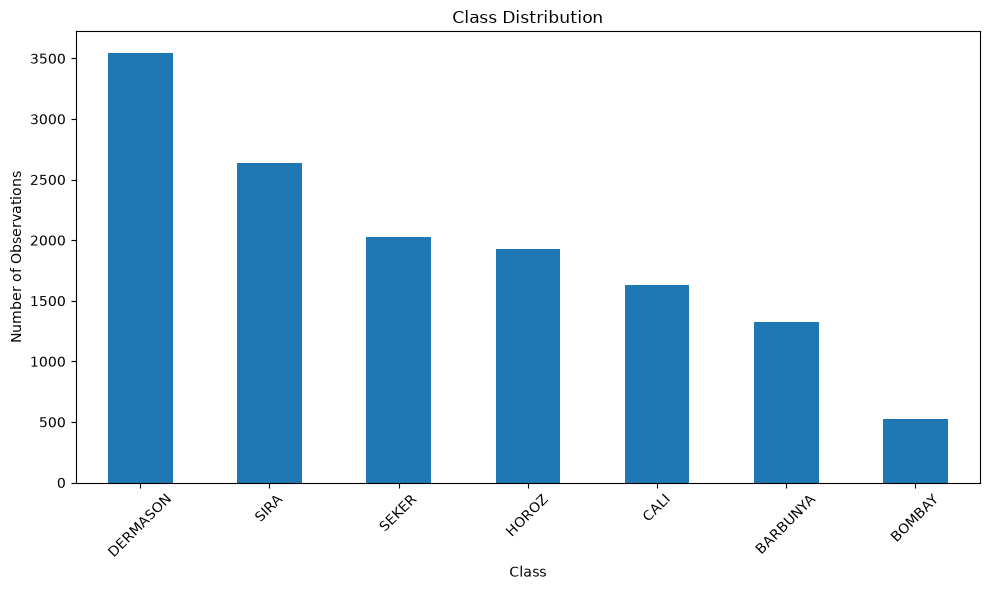

In [137]:
# Plot the number of observations in each class
plt.figure(figsize=(10, 6))
class_counts.plot(kind='bar')

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Observations")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Bar Plot Analysis
The bar plot gives a visual comparison of the number of observations in each class. It makes differences in class sizes easier to identify.

## Relationship Between Area and Perimeter


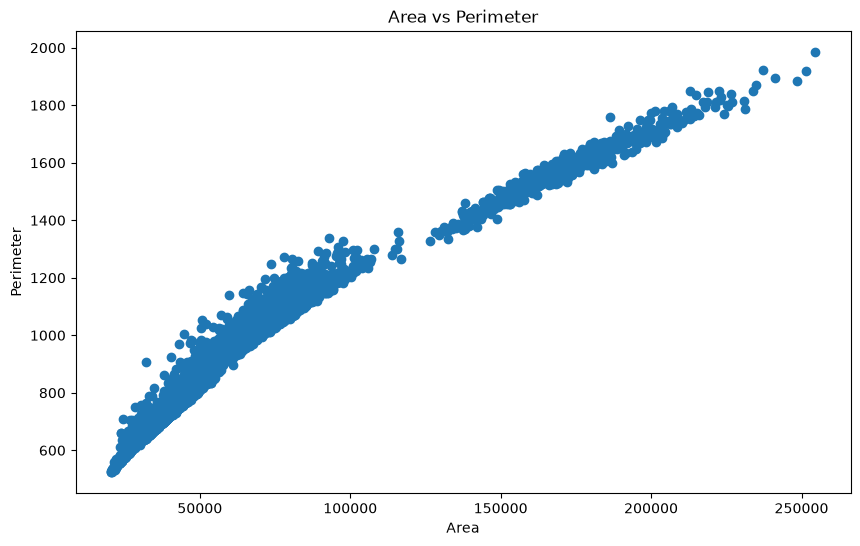

In [138]:
# Plot the relationship between Area and Perimeter
plt.figure(figsize=(10, 6))
plt.scatter(df['Area'], df['Perimeter'])

plt.title("Area vs Perimeter")
plt.xlabel("Area")
plt.ylabel("Perimeter")
plt.show()

# Scatter Plot Analysis
The scatter plot shows the relationship between Area and Perimeter. It helps us see whether the two numerical attributes change together and whether the observations form a clear pattern.

## Correlation Coefficient


In [139]:
# Calculate the correlation coefficient between Area and Perimeter
correlation = np.corrcoef(df['Area'], df['Perimeter'])[0, 1]

print("Correlation coefficient between Area and Perimeter:", correlation)

Correlation coefficient between Area and Perimeter: 0.9667221821788792


# Correlation Analysis
The correlation coefficient measures the strength and direction of the linear relationship between Area and Perimeter. A value close to 1 indicates a strong positive relationship, while a value close to 0 indicates a weak linear relationship.

# Data Distribution and Relationships Findings
The missing-value check determines whether missing-value treatment is required. The class distribution and bar plot show how the observations are distributed among the bean classes. The scatter plot and correlation coefficient provide information about the relationship between Area and Perimeter. These findings, together with the statistical summaries, boxplots, and histograms in the previous section, help identify suitable preprocessing techniques.

# Data Preprocessing
## 1. Noise Removal

The boxplot analysis and IQR method identified potential outliers in several numerical attributes, including Eccentricity, Solidity, ShapeFactor4, MinorAxisLength, Area, and ConvexArea. Therefore, the Interquartile Range (IQR) method was applied to remove observations containing values outside the lower and upper IQR boundaries.

In [140]:
import pandas as pd

df = pd.read_csv("Raw_dataset.csv")

print("Dataset shape:", df.shape)

Dataset shape: (13611, 17)


In [141]:
# Create a copy of the original dataset
Preprocessed_dataset = df.copy()

print("Original dataset shape:", Preprocessed_dataset.shape)

Original dataset shape: (13611, 17)


In [142]:
Q1 = Preprocessed_dataset[numeric_columns].quantile(0.25)
Q3 = Preprocessed_dataset[numeric_columns].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [143]:
numeric_columns = df.select_dtypes(include='number').columns

print(numeric_columns)

Index(['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength',
       'AspectRation', 'Eccentricity', 'ConvexArea', 'EquivDiameter', 'Extent',
       'Solidity', 'roundness', 'Compactness', 'ShapeFactor1', 'ShapeFactor2',
       'ShapeFactor3', 'ShapeFactor4'],
      dtype='str')


In [144]:
outlier_mask = (
    (Preprocessed_dataset[numeric_columns] < lower_bound) |
    (Preprocessed_dataset[numeric_columns] > upper_bound)
).any(axis=1)

In [145]:
Preprocessed_dataset = Preprocessed_dataset.loc[~outlier_mask].copy()

print("Preprocessed dataset shape:", Preprocessed_dataset.shape)
print("Number of rows removed:", len(df) - len(Preprocessed_dataset))

Preprocessed dataset shape: (10594, 17)
Number of rows removed: 3017


In [146]:
Preprocessed_dataset.head()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
23,31637,656.711,229.719255,175.510446,1.308864,0.645191,32045,200.702465,0.761823,0.987268,0.921842,0.873686,0.007261,0.002610,0.763327,0.999091,SEKER
24,31675,657.431,236.752632,171.210559,1.382816,0.690678,32009,200.822963,0.740936,0.989565,0.920929,0.848240,0.007474,0.002387,0.719510,0.994950,SEKER
29,31811,642.092,223.984683,180.917123,1.238051,0.589565,32052,201.253629,0.773877,0.992481,0.969600,0.898515,0.007041,0.002831,0.807329,0.999515,SEKER
31,31823,662.532,222.872689,181.894696,1.225284,0.577858,32274,201.291585,0.774848,0.986026,0.911040,0.903168,0.007004,0.002875,0.815713,0.999481,SEKER
32,31837,656.404,224.912554,180.439422,1.246471,0.596968,32238,201.335857,0.785246,0.987561,0.928538,0.895174,0.007065,0.002798,0.801336,0.998843,SEKER


### Noise Removal Result

After applying the IQR-based noise removal technique, 3,017 observations containing potential outliers were removed. The dataset size decreased from 13,611 to 10,594 observations, while the original dataset remained unchanged. This resulted in a cleaner dataset with reduced influence from extreme values, supporting more reliable analysis and subsequent preprocessing steps.

## 2- Normalization - Min-Max Normalization

Min-Max Normalization was applied to scale the numerical attributes to a common range between 0 and 1. This helps reduce the effect of different feature scales and makes the attributes more comparable.

In [147]:
numeric_columns = Preprocessed_dataset.select_dtypes(include='number').columns

In [148]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

Preprocessed_dataset[numeric_columns] = scaler.fit_transform(
    Preprocessed_dataset[numeric_columns]
)

In [149]:
Preprocessed_dataset.head()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
23,0.144085,0.175629,0.153681,0.275552,0.097342,0.230771,0.143456,0.205000,0.581897,0.536943,0.796207,0.861504,0.561625,0.717059,0.844851,0.949636,SEKER
24,0.144573,0.176587,0.177118,0.245015,0.179717,0.378736,0.143001,0.205626,0.498222,0.689107,0.792828,0.746637,0.606862,0.627263,0.720235,0.612246,SEKER
29,0.146320,0.156174,0.134571,0.313948,0.018464,0.049827,0.143544,0.207864,0.630184,0.882200,0.972922,0.973586,0.514979,0.806139,0.969997,0.984209,SEKER
31,0.146474,0.183375,0.130866,0.320891,0.004242,0.011746,0.146348,0.208061,0.634072,0.454687,0.756235,0.994592,0.507007,0.823732,0.993841,0.981378,SEKER
32,0.146654,0.175220,0.137663,0.310556,0.027843,0.073909,0.145893,0.208291,0.675725,0.556372,0.820982,0.958504,0.519940,0.793002,0.952952,0.929411,SEKER


### Min-Max Normalization Result

After applying Min-Max Normalization, all numerical attributes were scaled to a range between 0 and 1. The number of observations remained unchanged at 10,594. This normalization makes the numerical attributes comparable despite their different original scales.

## 3. Correlation Analysis and Feature Selection
Correlation Analysis was applied to examine the relationships between numerical attributes. The correlation coefficient measures the strength and direction of the relationship between two numerical attributes. Attributes with a high absolute correlation may provide redundant information, so highly correlated attributes can be considered for feature selection.

In [150]:
correlation_matrix = Preprocessed_dataset[numeric_columns].corr()

upper = correlation_matrix.where(
    np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
)

columns_to_remove = [
    column for column in upper.columns
    if any(upper[column].abs() > 0.75)
]

Preprocessed_dataset = Preprocessed_dataset.drop(columns=columns_to_remove)

print("Removed attributes:")
print(columns_to_remove)

print("\nPreprocessed dataset shape:")
print(Preprocessed_dataset.shape)
Preprocessed_dataset.to_csv('Preprocessed_dataset.csv', index=False)

Removed attributes:
['Perimeter', 'MajorAxisLength', 'MinorAxisLength', 'Eccentricity', 'ConvexArea', 'EquivDiameter', 'roundness', 'Compactness', 'ShapeFactor1', 'ShapeFactor2', 'ShapeFactor3']

Preprocessed dataset shape:
(10594, 6)


### Correlation Analysis Result

Correlation analysis identified several highly correlated numerical attributes. Attributes with an absolute correlation greater than 0.75 were removed to reduce redundancy. After feature selection, the preprocessed dataset contained 10,594 observations and 6 attributes.